# Proyecto de agronomia exploracion, analisis,

In [1]:
from __future__ import annotations

import argparse
import csv
from pathlib import Path

import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
import pandas as pd
import requests


Matplotlib is building the font cache; this may take a moment.


In [40]:
BASE_DIR = Path.cwd()

DATA_PATH = BASE_DIR / "data" / "agricola_2025.csv"
FIG_DIR = BASE_DIR / "figuras"
OUTPUT_DIR = BASE_DIR / "data" / "processed"

URL = (
    "https://nube.agricultura.gob.mx/index.php"
    "?view=10AE434F-A2158368-A120BC5A-EDF4AFAA&ANIO=2025"
)

TOP_N = 15

print("Directorio base:", BASE_DIR)
print("Ruta de datos:", DATA_PATH)

Directorio base: b:\MCD2\JW\agro\proyecto_agronomia
Ruta de datos: b:\MCD2\JW\agro\proyecto_agronomia\data\agricola_2025.csv


In [41]:
def descargar_datos(url, ruta_destino):
    ruta_destino.parent.mkdir(parents=True, exist_ok=True)

    if ruta_destino.exists():
        print(f"El archivo ya existe: {ruta_destino}")
        return

    print("Descargando datos agrícolas 2025...")

    response = requests.get(url, timeout=120)
    response.raise_for_status()

    ruta_destino.write_bytes(response.content)

    print(f"Descarga completada: {ruta_destino}")
    print(
        f"Tamaño: {ruta_destino.stat().st_size / (1024**2):.2f} MB"
    )


descargar_datos(URL, DATA_PATH)

El archivo ya existe: b:\MCD2\JW\agro\proyecto_agronomia\data\agricola_2025.csv


In [42]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print(df.shape)
df.head()

(35902, 24)


,Anio,Idestado,Nomestado,Idddr,Nomddr,Idcader,Nomcader,Idmunicipio,Nommunicipio,Idciclo,...,Nomunidad,Idcultivo,Nomcultivo,Sembrada,Cosechada,Siniestrada,Volumenproduccion,Rendimiento,Preciomediorural,Valorproduccion
0,2025,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,1,...,Tonelada,5490000,Avena forrajera en verde,1500.0,1500.0,0.0,35250.0,23.50,654.00,23053500.00
1,2025,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,1,...,Tonelada,5670000,Brócoli,50.0,50.0,0.0,850.0,17.00,6887.78,5854613.00
2,2025,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,2,...,Tonelada,5490000,Avena forrajera en verde,165.0,165.0,0.0,3700.0,22.42,645.00,2386500.00
3,2025,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,2,...,Tonelada,5670000,Brócoli,60.0,60.0,0.0,785.2,13.09,5161.69,4052958.99
4,2025,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,1,Aguascalientes,2,...,Tonelada,5740000,Calabacita,30.0,30.0,0.0,490.0,16.33,5285.21,2589752.90


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35902 entries, 0 to 35901
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Anio                35902 non-null  int64  
 1   Idestado            35902 non-null  int64  
 2   Nomestado           35902 non-null  str    
 3   Idddr               35902 non-null  int64  
 4   Nomddr              35902 non-null  str    
 5   Idcader             35902 non-null  int64  
 6   Nomcader            35902 non-null  str    
 7   Idmunicipio         35902 non-null  int64  
 8   Nommunicipio        35902 non-null  str    
 9   Idciclo             35902 non-null  int64  
 10  Nomcicloproductivo  35902 non-null  str    
 11  Idmodalidad         35902 non-null  int64  
 12  Nommodalidad        35902 non-null  str    
 13  Idunidadmedida      35902 non-null  int64  
 14  Nomunidad           35902 non-null  str    
 15  Idcultivo           35902 non-null  int64  
 16  Nomcultivo     

In [15]:
df.isna().sum().sort_values(ascending=False)

Preciomediorural      415
Rendimiento           415
Anio                    0
Idestado                0
Nomddr                  0
Idcader                 0
Nomestado               0
Idddr                   0
Idmunicipio             0
Nomcader                0
Nommunicipio            0
Idciclo                 0
Nommodalidad            0
Idunidadmedida          0
Nomcicloproductivo      0
Idmodalidad             0
Idcultivo               0
Nomunidad               0
Nomcultivo              0
Sembrada                0
Siniestrada             0
Cosechada               0
Volumenproduccion       0
Valorproduccion         0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
print("Estados:", df["Nomestado"].nunique())
print("Municipios:", df["Nommunicipio"].nunique())
print("Cultivos:", df["Nomcultivo"].nunique())
print("Ciclos productivos:", df["Nomcicloproductivo"].nunique())
print("Modalidades:", df["Nommodalidad"].nunique())

Estados: 32
Municipios: 2304
Cultivos: 288
Ciclos productivos: 3
Modalidades: 2


## 1. Exploración inicial del conjunto de datos

El conjunto de datos contiene **35,902 registros y 24 variables** correspondientes a la producción agrícola de México durante 2025.

La información presenta una cobertura amplia del territorio y de la actividad agrícola nacional:

- **32 estados**
- **2,304 municipios**
- **288 cultivos**
- **3 ciclos productivos**
- **2 modalidades de producción**

Cada registro combina información geográfica y productiva, incluyendo la superficie sembrada, cosechada y siniestrada, así como el volumen de producción, rendimiento, precio medio rural y valor de producción.

### Calidad inicial de los datos

La revisión inicial muestra un conjunto de datos considerablemente completo:

- No se encontraron registros duplicados.
- 22 de las 24 variables no presentan valores faltantes.
- `Rendimiento` contiene **415 valores faltantes**.
- `Preciomediorural` contiene **415 valores faltantes**.

Estos valores representan aproximadamente el **1.16 %** de las 35,902 observaciones, por lo que será necesario estudiar su origen antes de decidir si deben eliminarse, imputarse o conservarse.

La coincidencia en el número de valores faltantes de `Rendimiento` y `Preciomediorural` también plantea una primera pregunta para la exploración: **¿corresponden ambos faltantes a los mismos registros y existe alguna característica productiva que los explique?**

En las siguientes secciones se analizará la estructura de estos registros antes de comenzar el análisis de la producción agrícola.

In [18]:
faltantes = df[
    df["Rendimiento"].isna() |
    df["Preciomediorural"].isna()
].copy()

print("Registros con algún faltante:", len(faltantes))

print(
    "Faltantes simultáneos:",
    (
        df["Rendimiento"].isna()
        & df["Preciomediorural"].isna()
    ).sum()
)

faltantes[
    [
        "Nomestado",
        "Nommunicipio",
        "Nomcultivo",
        "Nomcicloproductivo",
        "Nommodalidad",
        "Sembrada",
        "Cosechada",
        "Siniestrada",
        "Volumenproduccion",
        "Rendimiento",
        "Preciomediorural",
        "Valorproduccion"
    ]
].head(20)

Registros con algún faltante: 415
Faltantes simultáneos: 415


,Nomestado,Nommunicipio,Nomcultivo,Nomcicloproductivo,Nommodalidad,Sembrada,Cosechada,Siniestrada,Volumenproduccion,Rendimiento,Preciomediorural,Valorproduccion
28,Aguascalientes,Aguascalientes,Agave,Perennes,Temporal,8.0,0.0,0.0,0.0,NaN,NaN,0.0
111,Aguascalientes,San Francisco de Los Romo,Nuez,Perennes,Riego,79.0,0.0,0.0,0.0,NaN,NaN,0.0
344,Baja California,Playas de Rosarito,Uva,Perennes,Riego,4.0,0.0,4.0,0.0,NaN,NaN,0.0
367,Baja California,Tecate,Palma de ornato,Perennes,Riego,2.0,0.0,2.0,0.0,NaN,NaN,0.0
384,Baja California,Ensenada,Avena forrajera en verde,Otoño-Invierno,Temporal,4.0,0.0,4.0,0.0,NaN,NaN,0.0
385,Baja California,Ensenada,Avena grano,Otoño-Invierno,Temporal,1900.0,0.0,1900.0,0.0,NaN,NaN,0.0
386,Baja California,Ensenada,Cebada forrajera en verde,Otoño-Invierno,Temporal,15.0,0.0,15.0,0.0,NaN,NaN,0.0
387,Baja California,Ensenada,Cebada grano,Otoño-Invierno,Temporal,1800.0,0.0,1800.0,0.0,NaN,NaN,0.0
388,Baja California,Ensenada,Trigo grano,Otoño-Invierno,Temporal,260.0,0.0,260.0,0.0,NaN,NaN,0.0
405,Baja California,Ensenada,Agave,Perennes,Riego,10.0,0.0,0.0,0.0,NaN,NaN,0.0


In [19]:
validacion_faltantes = pd.Series({
    "Total registros con faltantes": len(faltantes),
    "Cosechada = 0": (faltantes["Cosechada"] == 0).sum(),
    "Volumenproduccion = 0": (faltantes["Volumenproduccion"] == 0).sum(),
    "Valorproduccion = 0": (faltantes["Valorproduccion"] == 0).sum(),
    "Siniestrada > 0": (faltantes["Siniestrada"] > 0).sum(),
})

validacion_faltantes

Total registros con faltantes    415
Cosechada = 0                    415
Volumenproduccion = 0            415
Valorproduccion = 0              415
Siniestrada > 0                   87
dtype: int64

In [20]:
faltantes["Situacion"] = "Sin cosecha"

faltantes.loc[
    faltantes["Siniestrada"] > 0,
    "Situacion"
] = "Superficie siniestrada"

faltantes["Situacion"].value_counts()

Situacion
Sin cosecha               328
Superficie siniestrada     87
Name: count, dtype: int64

### Interpretación de los valores faltantes

Los **415 registros** con valores faltantes en `Rendimiento` y
`Preciomediorural` corresponden exactamente a las mismas observaciones.

La inspección de estos registros muestra que, en los 415 casos:

- la superficie cosechada es igual a cero;
- el volumen de producción es igual a cero;
- el valor de producción es igual a cero.

Este patrón indica que los valores faltantes no parecen ser simplemente errores
de captura. En estos registros no se obtuvo una cosecha registrada y, por lo
tanto, algunas variables productivas dejan de ser aplicables.

El rendimiento puede expresarse como:

\[
\text{Rendimiento} =
\frac{\text{Volumen de producción}}
{\text{Superficie cosechada}}
\]

Cuando la superficie cosechada y el volumen producido son ambos cero, el
rendimiento no puede calcularse. Por esta razón, conservar `NaN` resulta más
apropiado que sustituir estos valores por cero.

La misma situación explica la ausencia de `Preciomediorural`: al no existir
volumen de producción registrado, tampoco existe un precio medio asociado a
esa producción.

#### Dos situaciones dentro de los registros sin cosecha

Los 415 registros pueden dividirse en:

| Situación | Registros |
|---|---:|
| Sin cosecha y sin superficie registrada como siniestrada | 328 |
| Con superficie siniestrada | 87 |
| **Total** | **415** |

Esta distinción es particularmente importante para el proyecto. Una superficie
sembrada que posteriormente aparece como siniestrada representa un fenómeno
diferente de una superficie que simplemente no registra cosecha.

Por este motivo, **no se eliminarán ni imputarán automáticamente estos 415
registros**. La ausencia de producción puede contener información relevante
para analizar posteriormente el éxito o fracaso de una actividad agrícola.

## 2. Estructura de las observaciones

Antes de comparar estados, cultivos o niveles de producción, es necesario
determinar qué representa exactamente cada fila del conjunto de datos.

A partir de las variables disponibles, una observación parece describir la
actividad de un cultivo en un municipio determinado, bajo un ciclo productivo
y una modalidad de producción específicos.

A continuación se verificará si esta combinación identifica de manera única
las observaciones del conjunto de datos.

In [21]:
clave = [
    "Nomestado",
    "Nommunicipio",
    "Nomcultivo",
    "Nomcicloproductivo",
    "Nommodalidad"
]

df.duplicated(subset=clave).sum()

np.int64(1070)

In [22]:
duplicados_clave = df[
    df.duplicated(subset=clave, keep=False)
].sort_values(clave)

print("Filas involucradas:", len(duplicados_clave))

duplicados_clave[
    [
        "Nomestado",
        "Nommunicipio",
        "Nomddr",
        "Nomcader",
        "Nomcultivo",
        "Nomcicloproductivo",
        "Nommodalidad",
        "Sembrada",
        "Cosechada",
        "Siniestrada",
        "Volumenproduccion"
    ]
].head(30)

Filas involucradas: 1797


,Nomestado,Nommunicipio,Nomddr,Nomcader,Nomcultivo,Nomcicloproductivo,Nommodalidad,Sembrada,Cosechada,Siniestrada,Volumenproduccion
280,Aguascalientes,Asientos,Aguascalientes,Villa Juárez,Chile verde,Primavera-Verano,Riego,70.0,70.00,0.0,685.00
281,Aguascalientes,Asientos,Aguascalientes,Villa Juárez,Chile verde,Primavera-Verano,Riego,360.0,360.00,0.0,6519.38
404,Baja California,Ensenada,Ensenada,Ensenada,Aceituna,Perennes,Riego,1193.5,1193.50,0.0,3857.19
436,Baja California,Ensenada,Ensenada,San Quintín,Aceituna,Perennes,Riego,104.0,0.00,104.0,0.00
406,Baja California,Ensenada,Ensenada,Ensenada,Aguacate,Perennes,Riego,20.0,10.00,0.0,62.00
437,Baja California,Ensenada,Ensenada,San Quintín,Aguacate,Perennes,Riego,20.0,0.00,20.0,0.00
407,Baja California,Ensenada,Ensenada,Ensenada,Alfalfa,Perennes,Riego,117.0,117.00,0.0,11445.00
438,Baja California,Ensenada,Ensenada,San Quintín,Alfalfa,Perennes,Riego,8.0,8.00,0.0,655.60
408,Baja California,Ensenada,Ensenada,Ensenada,Arándano,Perennes,Riego,33.0,33.00,0.0,570.90
439,Baja California,Ensenada,Ensenada,San Quintín,Arándano,Perennes,Riego,305.0,305.00,0.0,4353.30


In [23]:
clave_cader = [
    "Idestado",
    "Idmunicipio",
    "Idcader",
    "Idcultivo",
    "Idciclo",
    "Idmodalidad"
]

print(
    "Duplicados incluyendo CADER:",
    df.duplicated(subset=clave_cader).sum()
)

Duplicados incluyendo CADER: 56


In [24]:
clave_completa = [
    "Idestado",
    "Idddr",
    "Idcader",
    "Idmunicipio",
    "Idcultivo",
    "Idciclo",
    "Idmodalidad"
]

print(
    "Duplicados con jerarquía completa:",
    df.duplicated(subset=clave_completa).sum()
)

Duplicados con jerarquía completa: 1


In [25]:
df.loc[
    (df["Nomestado"] == "Baja California")
    & (df["Nommunicipio"] == "Ensenada")
    & (df["Nomcader"] == "Ensenada")
    & (df["Nomcultivo"] == "Flor cera")
    & (df["Nomcicloproductivo"] == "Perennes")
    & (df["Nommodalidad"] == "Riego"),
    [
        "Idcultivo",
        "Nomcultivo",
        "Idunidadmedida",
        "Nomunidad",
        "Sembrada",
        "Cosechada",
        "Volumenproduccion",
        "Rendimiento",
        "Preciomediorural",
        "Valorproduccion"
    ]
]

,Idcultivo,Nomcultivo,Idunidadmedida,Nomunidad,Sembrada,Cosechada,Volumenproduccion,Rendimiento,Preciomediorural,Valorproduccion
413,6700000,Flor cera,200201,Tonelada,66.5,66.5,565.25,8.5,18000.0,10174500.0
414,6700000,Flor cera,200203,Gruesa,35.0,35.0,13825.00,395.0,800.0,11060000.0


In [26]:
clave_final = [
    "Idestado",
    "Idddr",
    "Idcader",
    "Idmunicipio",
    "Idcultivo",
    "Idciclo",
    "Idmodalidad",
    "Idunidadmedida"
]

print(
    "Duplicados con unidad de medida:",
    df.duplicated(subset=clave_final).sum()
)

Duplicados con unidad de medida: 0


In [27]:
df["Nomunidad"].value_counts()

Nomunidad
Tonelada          35310
Gruesa              266
Planta              133
Miles de lts.       104
Manojo               72
Metro cuadrado       17
Name: count, dtype: int64

### Granularidad de las observaciones

El análisis de posibles duplicados permitió determinar con mayor precisión qué
representa una observación dentro del conjunto de datos.

La combinación inicial de estado, municipio, cultivo, ciclo productivo y
modalidad produjo **1,070 coincidencias adicionales**, aunque previamente se
había comprobado que no existen filas completamente duplicadas.

Al incorporar progresivamente la estructura administrativa agrícola, las
coincidencias disminuyeron:

- incluyendo el **CADER**: 56 coincidencias;
- incluyendo **CADER y DDR**: 1 coincidencia;
- incluyendo además la **unidad de medida**: 0 coincidencias.

Por lo tanto, una observación queda identificada mediante la combinación de:

- Estado
- DDR (Distrito de Desarrollo Rural)
- CADER (Centro de Apoyo al Desarrollo Rural)
- Municipio
- Cultivo
- Ciclo productivo
- Modalidad
- Unidad de medida

Esta granularidad será importante al realizar agregaciones posteriores, ya que
un mismo cultivo dentro de un municipio puede aparecer en diferentes unidades
administrativas o incluso utilizar distintas unidades de medida.

### Unidades de producción

Aunque la gran mayoría de las observaciones utilizan **toneladas** como unidad
de producción, el conjunto de datos contiene seis unidades diferentes:

| Unidad | Registros |
|---|---:|
| Tonelada | 35,310 |
| Gruesa | 266 |
| Planta | 133 |
| Miles de lts. | 104 |
| Manojo | 72 |
| Metro cuadrado | 17 |

Las observaciones expresadas en toneladas representan aproximadamente el
**98.35 %** del conjunto de datos.

Esta diferencia es relevante porque `Volumenproduccion` no puede agregarse
directamente entre unidades incompatibles. Por ejemplo, una producción
expresada en toneladas no debe sumarse con otra expresada en gruesas, plantas
o miles de litros.

Por esta razón, los análisis basados en volumen de producción deberán
considerar explícitamente la unidad de medida. Cuando se requieran
comparaciones agregadas entre cultivos, se utilizarán variables compatibles o
se restringirá el análisis a observaciones con unidades comparables.

# 3. Panorama de la producción agrícola en México

Una vez examinada la estructura y calidad del conjunto de datos, el siguiente
paso consiste en explorar cómo se distribuye la actividad agrícola registrada
durante 2025.

El análisis comenzará desde una perspectiva nacional y posteriormente
descenderá hacia estados, municipios y cultivos específicos.

Las primeras preguntas son:

1. ¿Qué cultivos concentran el mayor valor de producción?
2. ¿Qué estados concentran la mayor actividad agrícola?
3. ¿Cómo se relacionan la superficie sembrada, la superficie cosechada y la
   superficie siniestrada?
4. ¿Existen diferencias importantes entre agricultura de riego y temporal?
5. ¿Qué patrones pueden observarse entre cultivos, regiones y rendimiento?

In [34]:
top_valor_cultivos = (
    df.groupby("Nomcultivo", as_index=False)
      .agg(
          Valorproduccion=("Valorproduccion", "sum"),
          Sembrada=("Sembrada", "sum"),
          Cosechada=("Cosechada", "sum")
      )
      .sort_values("Valorproduccion", ascending=False)
      .head(15)
)

top_valor_cultivos

,Nomcultivo,Valorproduccion,Sembrada,Cosechada
168,Maíz grano,1.265495e+11,6759367.86,6662685.49
5,Aguacate,5.958966e+10,268311.95,255660.41
52,Caña de azúcar,5.605554e+10,855518.88,796843.88
62,Chile verde,3.822126e+10,144247.09,143843.50
198,Pastos y praderas,3.713464e+10,2550251.91,2531402.67
262,Tomate rojo (jitomate),2.960228e+10,42394.77,42119.42
179,Naranja,2.907278e+10,355493.01,343904.66
12,Alfalfa,2.516113e+10,400843.13,400840.13
148,Limón,2.439684e+10,231798.65,217159.76
104,Frijol,2.354924e+10,1545936.00,1526523.09


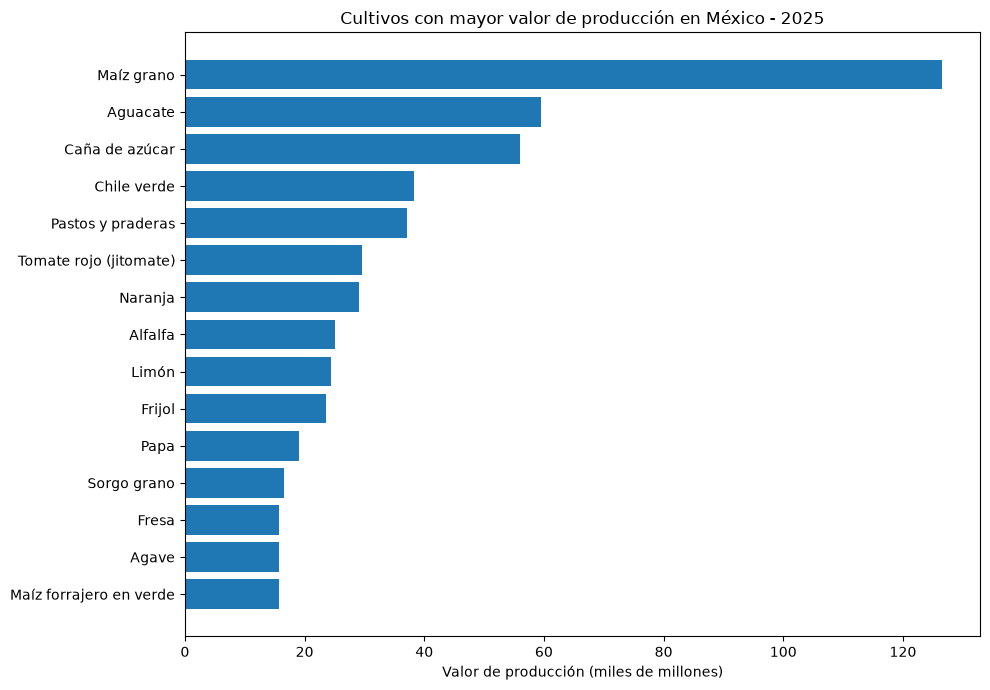

In [35]:
top_valor_plot = top_valor_cultivos.copy()

top_valor_plot["Valor_miles_millones"] = (
    top_valor_plot["Valorproduccion"] / 1e9
)

top_valor_plot = top_valor_plot.sort_values(
    "Valor_miles_millones",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_valor_plot["Nomcultivo"],
    top_valor_plot["Valor_miles_millones"]
)

plt.title(
    "Cultivos con mayor valor de producción en México - 2025"
)
plt.xlabel("Valor de producción (miles de millones)")
plt.ylabel("")

plt.tight_layout()
plt.show()

### ¿Qué cultivos concentran el mayor valor de producción?

El valor económico de la producción agrícola no se distribuye de manera
uniforme entre los diferentes cultivos.

El **maíz grano** ocupa la primera posición con aproximadamente **126.5 mil
millones** en valor de producción, mostrando una diferencia considerable
respecto al resto de los cultivos.

En el siguiente grupo destacan el **aguacate** y la **caña de azúcar**, con
aproximadamente 59.6 y 56.1 mil millones, respectivamente. También aparecen
entre las primeras posiciones cultivos como chile verde, tomate rojo, naranja,
alfalfa y limón.

Sin embargo, el valor total no necesariamente refleja la cantidad de
superficie utilizada. Algunos cultivos alcanzan un valor elevado utilizando
una superficie considerablemente menor que otros.

Por ejemplo, el aguacate se encuentra en la segunda posición por valor de
producción con alrededor de 268 mil unidades de superficie sembrada, mientras
que el maíz grano supera los 6.7 millones.

Esto plantea una nueva pregunta:

> **¿Qué relación existe entre la superficie destinada a un cultivo y el valor
> económico que genera?**

In [36]:
cultivos_resumen = (
    df.groupby("Nomcultivo", as_index=False)
      .agg(
          Sembrada=("Sembrada", "sum"),
          Cosechada=("Cosechada", "sum"),
          Valorproduccion=("Valorproduccion", "sum")
      )
)

cultivos_resumen.head()

,Nomcultivo,Sembrada,Cosechada,Valorproduccion
0,Aceituna,5600.40,5464.50,3.507232e+08
1,Acelga,697.82,674.87,4.534153e+07
2,Achiote,1042.50,936.50,2.576447e+07
3,Agapando,147.01,147.01,2.138483e+07
4,Agave,307130.88,40974.81,1.579857e+10


### Superficie sembrada y valor de producción

El ranking anterior mostró que algunos cultivos alcanzan valores de producción
elevados utilizando superficies considerablemente menores que otros.

Para explorar esta relación se compara, para cada cultivo, la superficie
sembrada total con su valor de producción agregado durante 2025.

Si una mayor superficie implicara proporcionalmente un mayor valor de
producción, esperaríamos observar una relación relativamente uniforme entre
ambas variables. Sin embargo, la diversidad de cultivos y sistemas productivos
puede generar comportamientos muy diferentes.

Esta comparación permitirá identificar cultivos que se alejan del patrón
general y plantear nuevas preguntas sobre el valor generado por unidad de
superficie.

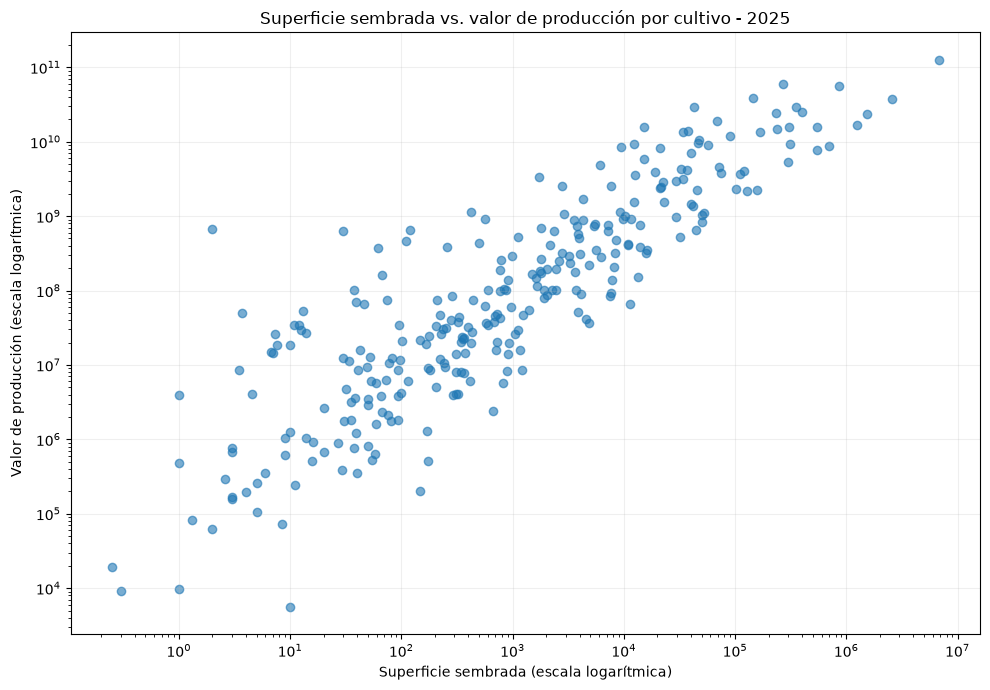

In [37]:
cultivos_plot = cultivos_resumen[
    (cultivos_resumen["Sembrada"] > 0) &
    (cultivos_resumen["Valorproduccion"] > 0)
].copy()

plt.figure(figsize=(10, 7))

plt.scatter(
    cultivos_plot["Sembrada"],
    cultivos_plot["Valorproduccion"],
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Superficie sembrada vs. valor de producción por cultivo - 2025"
)
plt.xlabel("Superficie sembrada (escala logarítmica)")
plt.ylabel("Valor de producción (escala logarítmica)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

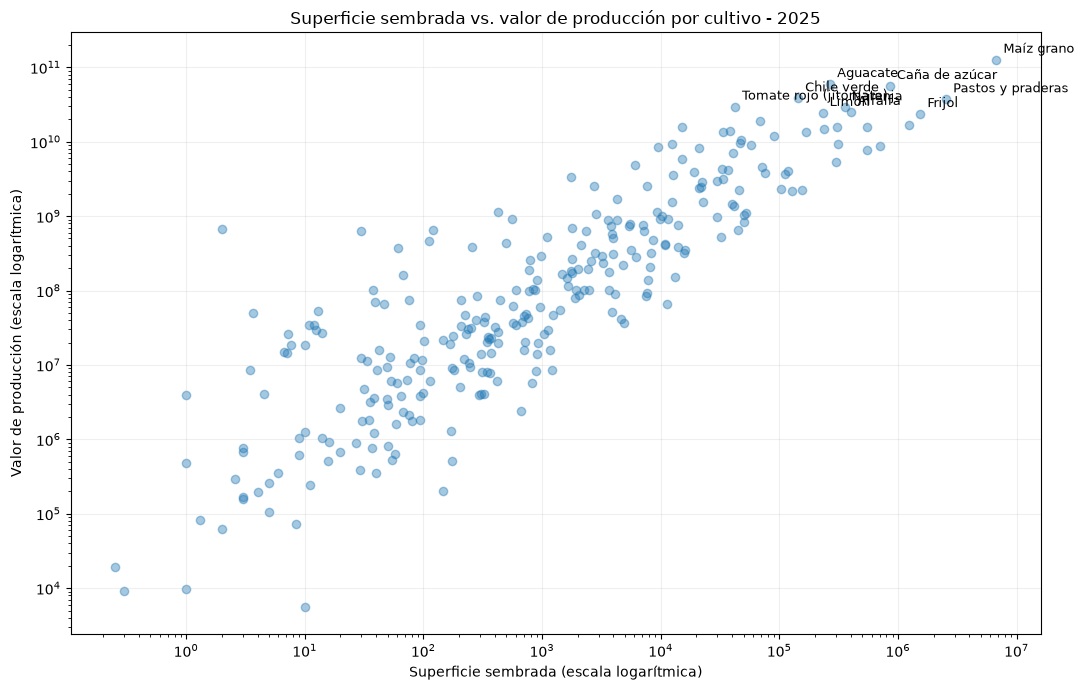

In [38]:
destacados = (
    cultivos_plot
    .nlargest(10, "Valorproduccion")
)

plt.figure(figsize=(11, 7))

plt.scatter(
    cultivos_plot["Sembrada"],
    cultivos_plot["Valorproduccion"],
    alpha=0.4
)

for _, fila in destacados.iterrows():
    plt.annotate(
        fila["Nomcultivo"],
        (fila["Sembrada"], fila["Valorproduccion"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Superficie sembrada vs. valor de producción por cultivo - 2025"
)
plt.xlabel("Superficie sembrada (escala logarítmica)")
plt.ylabel("Valor de producción (escala logarítmica)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [39]:
cultivos_resumen["Valor_por_superficie"] = (
    cultivos_resumen["Valorproduccion"]
    / cultivos_resumen["Sembrada"]
)

cultivos_resumen[
    [
        "Nomcultivo",
        "Sembrada",
        "Valorproduccion",
        "Valor_por_superficie"
    ]
].sort_values(
    "Valor_por_superficie",
    ascending=False
).head(20)

,Nomcultivo,Sembrada,Valorproduccion,Valor_por_superficie
277,Viveros de durazno,2.00,6.732000e+08,3.366000e+08
271,Tulipán holandés,30.05,6.395486e+08,2.128281e+07
132,Hortensia,3.66,5.024019e+07,1.372683e+07
130,"Hongos, setas y champiñones",61.44,3.715036e+08,6.046608e+06
27,Aster,120.50,6.444016e+08,5.347731e+06
113,Gerbera,111.00,4.676495e+08,4.213059e+06
80,Cyclamen,12.93,5.234593e+07,4.048409e+06
19,Anturios,1.00,3.925091e+06,3.925091e+06
34,Begonia,7.27,2.585916e+07,3.556968e+06
68,Cineraria,10.79,3.425141e+07,3.174366e+06


### Valor de producción por superficie sembrada

Para complementar el análisis anterior se calculó un indicador simple de valor
generado respecto a la superficie sembrada:

\[
\text{Valor por superficie} =
\frac{\text{Valor de producción}}
{\text{Superficie sembrada}}
\]

Los resultados muestran una fuerte concentración de valores elevados en
cultivos ornamentales, flores, viveros y otros productos de producción
intensiva.

El caso más extremo corresponde a **Viveros de durazno**, con una superficie
sembrada registrada de solamente 2 unidades y un valor de producción de
aproximadamente 673.2 millones, lo que genera un indicador considerablemente
superior al resto de los cultivos.

También destacan productos como tulipán holandés, hortensia, hongos,
áster, gerbera, cyclamen y otras especies ornamentales.

Este resultado muestra una limitación importante de utilizar únicamente la
razón entre valor de producción y superficie sembrada para comparar cultivos.
Productos de alto valor e intensivos en superficie pueden presentar magnitudes
muy superiores a cultivos extensivos como maíz, frijol o sorgo.

Por lo tanto, este indicador **no debe interpretarse como rentabilidad** ni
como una recomendación directa sobre qué cultivo conviene sembrar. El conjunto
de datos no contiene información sobre costos de producción, inversión,
consumo de agua, mano de obra u otros factores necesarios para estimar
rentabilidad.

En cambio, el indicador resulta útil como herramienta exploratoria para
identificar diferencias entre sistemas productivos y detectar observaciones
que requieren un análisis más detallado.